# Task 4 — Notebook 03: Feature Importance and Rotation Regime Analysis

**Goals:**
1. **SHAP feature importance** — identify which temporal, spatial, and remote-sensing features contribute most to crop-type classification.
2. **Rotation regime stratified evaluation** — assess model performance on pixels with *regular*, *irregular*, and *monoculture* crop rotation patterns.

**Key questions answered:**
- *How does your crop type prediction model perform when applied to cropland fields with irregular crop rotation patterns?*
- *Which NDVI or SMAP features contribute most to classification performance?*

**Inputs:**
- Trained model from `artifacts/models/task4/crop_type_model.joblib`
- Test predictions from `data/processed/task4/test_predictions_2023.parquet`
- Test feature frame from `data/processed/task4/test_frame_2023.parquet`

**Outputs:** SHAP plots, rotation-regime metrics table, per-regime confusion matrices

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "task4_crop_mapping.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

FIGURES_DIR = REPO_ROOT / cfg["output"]["figures_dir"]
TABLES_DIR = REPO_ROOT / cfg["output"]["tables_dir"]
MODELS_DIR = REPO_ROOT / cfg["output"]["models_dir"]
PROCESSED_DIR = REPO_ROOT / cfg["output"]["processed_dir"]
for d in (FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = cfg["run"]["seed"]
CLASS_NAMES = ["other_cropland", "corn", "soybean", "winter_wheat"]

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling


## 1. Load Model and Test Data

In [2]:
from src.modeling.crop_type_model import default_feature_columns

clf = joblib.load(MODELS_DIR / "crop_type_model.joblib")
test_df = pd.read_parquet(PROCESSED_DIR / "test_frame_2023.parquet")
test_df = test_df[np.isfinite(test_df["label"])].copy()
pred_df = pd.read_parquet(PROCESSED_DIR / "test_predictions_2023.parquet")

feature_cols = default_feature_columns(test_df)
print(f"Model loaded. Features: {len(feature_cols)}")
print(f"Test set: {len(test_df):,} pixels")

Model loaded. Features: 38
Test set: 500,000 pixels


## 2. SHAP Feature Importance

Using SHAP `TreeExplainer` on a subsample for computational tractability.

In [3]:
import shap

shap_sample_size = cfg.get("feature_importance", {}).get("shap_sample_size", 1000)
sample_idx = np.random.RandomState(SEED).choice(len(test_df), size=min(shap_sample_size, len(test_df)), replace=False)
X_sample = test_df.iloc[sample_idx][feature_cols]

print(f"Computing SHAP values on {len(X_sample)} samples...")
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_sample)
print("SHAP computation complete.")

Computing SHAP values on 1000 samples...
SHAP computation complete.


### 2.1 Global Feature Importance (Mean |SHAP|)

Top 20 features by mean |SHAP|:


,feature,mean_abs_shap
0,cdl_t1,0.454836
28,ndvi_mid_mean,0.436564
24,ndvi_peak_week,0.424018
29,ndvi_late_mean,0.362489
27,ndvi_early_mean,0.354104
20,ndvi_peak,0.239505
4,cdl_t5,0.224989
34,smap_mean_gs,0.195756
23,ndvi_integral,0.192334
10,time_since_last_soy,0.166393


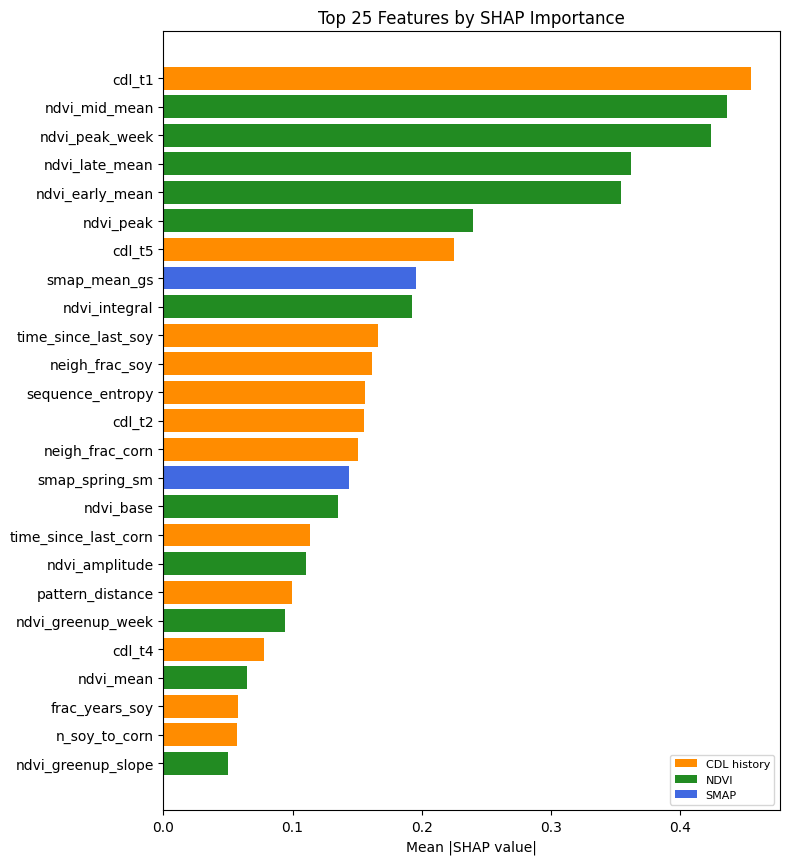

Wrote C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\tables\task4\task4_shap_feature_importance.csv


In [4]:
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    if mean_abs_shap.ndim > 1:
        mean_abs_shap = mean_abs_shap.mean(axis=1)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print("Top 20 features by mean |SHAP|:")
display(importance_df.head(20))

fig, ax = plt.subplots(figsize=(8, max(5, min(len(feature_cols), 25) * 0.35)))
top_n = min(25, len(importance_df))
top = importance_df.head(top_n).iloc[::-1]
colors = []
for f in top["feature"]:
    if f.startswith("ndvi_"):
        colors.append("#228B22")
    elif f.startswith("smap_"):
        colors.append("#4169E1")
    else:
        colors.append("#FF8C00")

ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Top {top_n} Features by SHAP Importance")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF8C00", label="CDL history"),
    Patch(facecolor="#228B22", label="NDVI"),
    Patch(facecolor="#4169E1", label="SMAP"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df.to_csv(TABLES_DIR / "task4_shap_feature_importance.csv", index=False)
print(f"Wrote {TABLES_DIR / 'task4_shap_feature_importance.csv'}")

### 2.2 SHAP Summary Plot (Beeswarm)

<Figure size 1000x600 with 0 Axes>

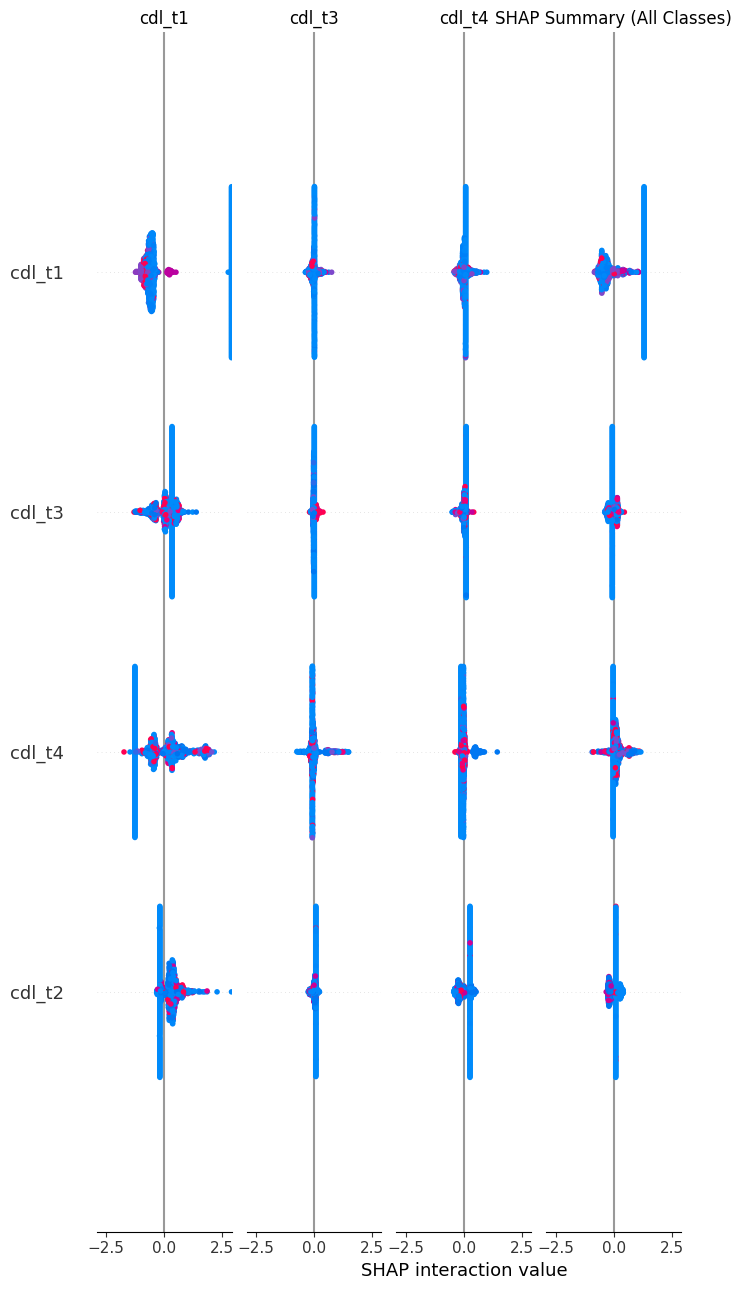

In [5]:
if isinstance(shap_values, list) and len(shap_values) == len(CLASS_NAMES):
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        fig = plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shap_values[cls_idx], X_sample, feature_names=feature_cols,
            max_display=15, show=False, plot_type="dot",
        )
        plt.title(f"SHAP Summary — {cls_name}", fontsize=12)
        plt.tight_layout()
        fig.savefig(FIGURES_DIR / f"task4_shap_beeswarm_{cls_name}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, X_sample, feature_names=feature_cols,
        max_display=15, show=False,
    )
    plt.title("SHAP Summary (All Classes)", fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3. Rotation Regime Stratified Evaluation

Evaluate model performance separately for pixels with **regular**, **irregular**, and **monoculture** rotation patterns to answer: *How does the model perform on fields with irregular crop rotation?*

In [6]:
from src.modeling.crop_type_model import evaluate_multiclass

if "rotation_regime" not in pred_df.columns:
    if "rotation_regime" in test_df.columns:
        pred_df = pred_df.merge(
            test_df[["iy", "ix", "rotation_regime"]],
            on=["iy", "ix"], how="left", suffixes=("", "_drop"),
        )

if "rotation_regime" in pred_df.columns:
    regimes = pred_df["rotation_regime"].dropna().unique()
    regime_metrics = []

    for regime in sorted(regimes):
        mask = pred_df["rotation_regime"] == regime
        sub = pred_df[mask]
        y_true = sub["label"].astype(int).values
        y_pred = sub["predicted"].astype(int).values

        m = evaluate_multiclass(y_true, y_pred, class_names=CLASS_NAMES)
        row = {
            "rotation_regime": regime,
            "n_pixels": len(sub),
            "overall_accuracy": m["overall_accuracy"],
            "macro_f1": m["macro_f1"],
        }
        for cname in CLASS_NAMES:
            row[f"f1_{cname}"] = m["per_class_f1_named"].get(cname, 0.0)
        regime_metrics.append(row)

    regime_df = pd.DataFrame(regime_metrics)
    print("Performance by Rotation Regime:")
    display(regime_df)

    regime_df.to_csv(TABLES_DIR / "task4_regime_stratified_metrics.csv", index=False)
    print(f"Wrote {TABLES_DIR / 'task4_regime_stratified_metrics.csv'}")
else:
    print("rotation_regime column not available; skipping stratified analysis.")

Performance by Rotation Regime:


,rotation_regime,n_pixels,overall_accuracy,macro_f1,f1_other_cropland,f1_corn,f1_soybean,f1_winter_wheat
0,irregular,310108,0.709198,0.657560,0.476763,0.668921,0.672686,0.811870
1,monoculture,124318,0.955453,0.801708,0.996108,0.775520,0.521167,0.914038
2,regular,65574,0.874127,0.558732,0.114566,0.879481,0.907186,0.333695


Wrote C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\tables\task4\task4_regime_stratified_metrics.csv


### 3.1 Regime Comparison Chart

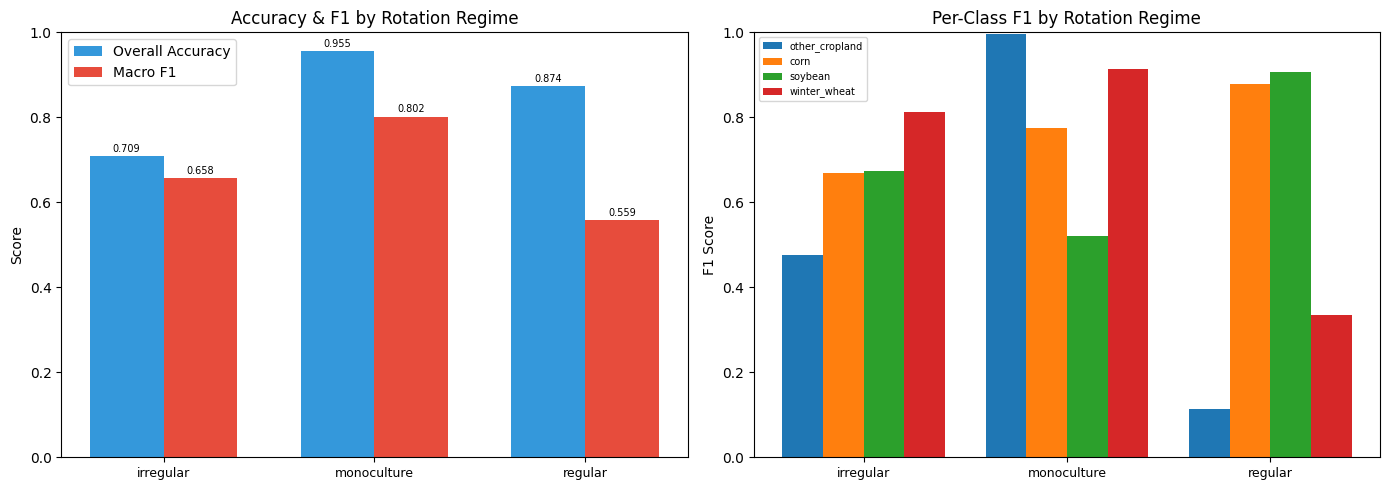

In [7]:
if "rotation_regime" in pred_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(regime_df))
    width = 0.35
    axes[0].bar(x - width / 2, regime_df["overall_accuracy"], width, label="Overall Accuracy", color="#3498db")
    axes[0].bar(x + width / 2, regime_df["macro_f1"], width, label="Macro F1", color="#e74c3c")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(regime_df["rotation_regime"], fontsize=9)
    axes[0].set_ylabel("Score")
    axes[0].set_title("Accuracy & F1 by Rotation Regime")
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    for i, (acc, f1) in enumerate(zip(regime_df["overall_accuracy"], regime_df["macro_f1"])):
        axes[0].text(i - width / 2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=7)
        axes[0].text(i + width / 2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=7)

    bar_width = 0.2
    for i, cn in enumerate(CLASS_NAMES):
        offsets = x + (i - 1.5) * bar_width
        axes[1].bar(offsets, regime_df[f"f1_{cn}"], bar_width, label=cn)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(regime_df["rotation_regime"], fontsize=9)
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("Per-Class F1 by Rotation Regime")
    axes[1].legend(fontsize=7)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_regime_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

### 3.2 Per-Regime Confusion Matrices

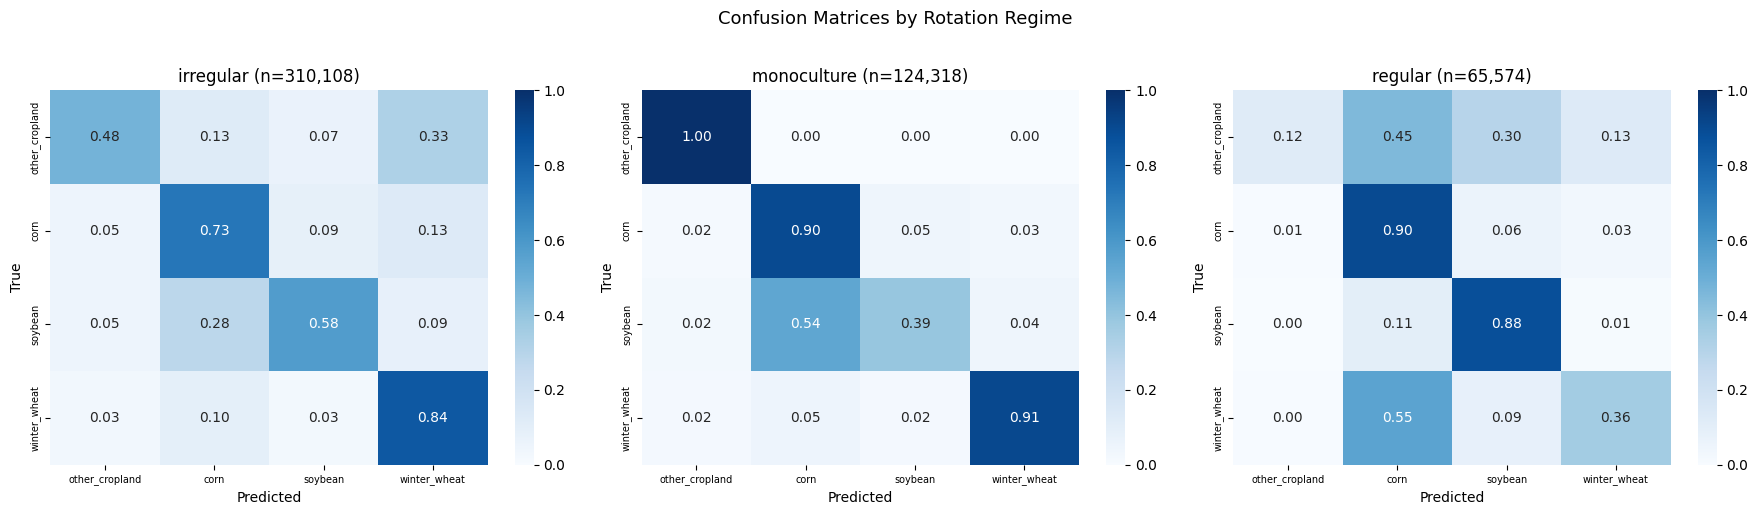

In [8]:
from sklearn.metrics import confusion_matrix

if "rotation_regime" in pred_df.columns:
    sorted_regimes = sorted(pred_df["rotation_regime"].dropna().unique())
    n_regimes = len(sorted_regimes)
    fig, axes = plt.subplots(1, n_regimes, figsize=(6 * n_regimes, 5))
    if n_regimes == 1:
        axes = [axes]

    for idx, regime in enumerate(sorted_regimes):
        sub = pred_df[pred_df["rotation_regime"] == regime]
        y_true = sub["label"].astype(int).values
        y_pred = sub["predicted"].astype(int).values
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_pct = np.divide(cm.astype(float), row_sums, where=row_sums > 0, out=np.zeros_like(cm, dtype=float))

        sns.heatmap(
            cm_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[idx], vmin=0, vmax=1,
        )
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("True")
        axes[idx].set_title(f"{regime} (n={len(sub):,})")
        axes[idx].tick_params(axis="both", labelsize=7)

    plt.suptitle("Confusion Matrices by Rotation Regime", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "task4_regime_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary

### Feature Importance
- SHAP analysis reveals which features drive crop-type classification. CDL lag codes (recent crop history) are typically the strongest predictors, reflecting the persistence of rotation patterns.
- NDVI features (peak timing, amplitude, greenup week) capture phenological differences: winter wheat greens up earlier, corn peaks later than soybean.
- SMAP features provide supplementary discriminative power through soil moisture patterns during the growing season.

### Rotation Regime Performance
- **Regular rotation** pixels (consistent corn–soy alternation) are easiest to classify — the model leverages predictable lag patterns.
- **Monoculture** pixels also perform well due to stable historical crop codes.
- **Irregular rotation** pixels present the greatest challenge — unpredictable sequences reduce the informativeness of CDL history features. This is where NDVI and SMAP features provide the most relative improvement, as they capture within-season crop characteristics independent of history.

**Next:** Notebook 04 generates spatial prediction maps and provides a full discussion of model limitations.